--- Generated 100 Stratified Random Architectures ---
Arch 001: 2 - 2 - 0 - 010000 - 0 - 1 - 010201 - 1
Arch 002: 1 - 2 - 1 - 100001 - 2 - 1 - 010220 - 0
Arch 003: 1 - 0 - 2 - 110101 - 2 - 0 - 012011 - 1
Arch 004: 1 - 0 - 0 - 000001 - 1 - 0 - 010211 - 1
Arch 005: 1 - 1 - 0 - 001000 - 2 - 1 - 011221 - 0
Arch 006: 1 - 1 - 0 - 010000 - 0 - 0 - 012120 - 1
Arch 007: 0 - 0 - 1 - 010100 - 1 - 0 - 010221 - 0
Arch 008: 2 - 0 - 0 - 010000 - 0 - 1 - 011112 - 1
Arch 009: 0 - 2 - 1 - 000101 - 0 - 0 - 001202 - 0
Arch 010: 0 - 1 - 0 - 010000 - 0 - 0 - 012120 - 1
Arch 011: 0 - 1 - 1 - 100100 - 0 - 1 - 012002 - 1
Arch 012: 0 - 0 - 2 - 101101 - 2 - 1 - 012221 - 1
Arch 013: 1 - 1 - 2 - 110101 - 2 - 1 - 011221 - 0
Arch 014: 0 - 1 - 2 - 110101 - 0 - 1 - 001001 - 0
Arch 015: 2 - 0 - 1 - 101000 - 1 - 1 - 010120 - 1
Arch 016: 0 - 1 - 0 - 001000 - 0 - 1 - 001001 - 0
Arch 017: 1 - 1 - 2 - 011101 - 0 - 1 - 011022 - 1
Arch 018: 1 - 1 - 2 - 101101 - 2 - 1 - 012102 - 0
Arch 019: 0 - 1 - 1 - 110000 - 0 - 0 - 001221 

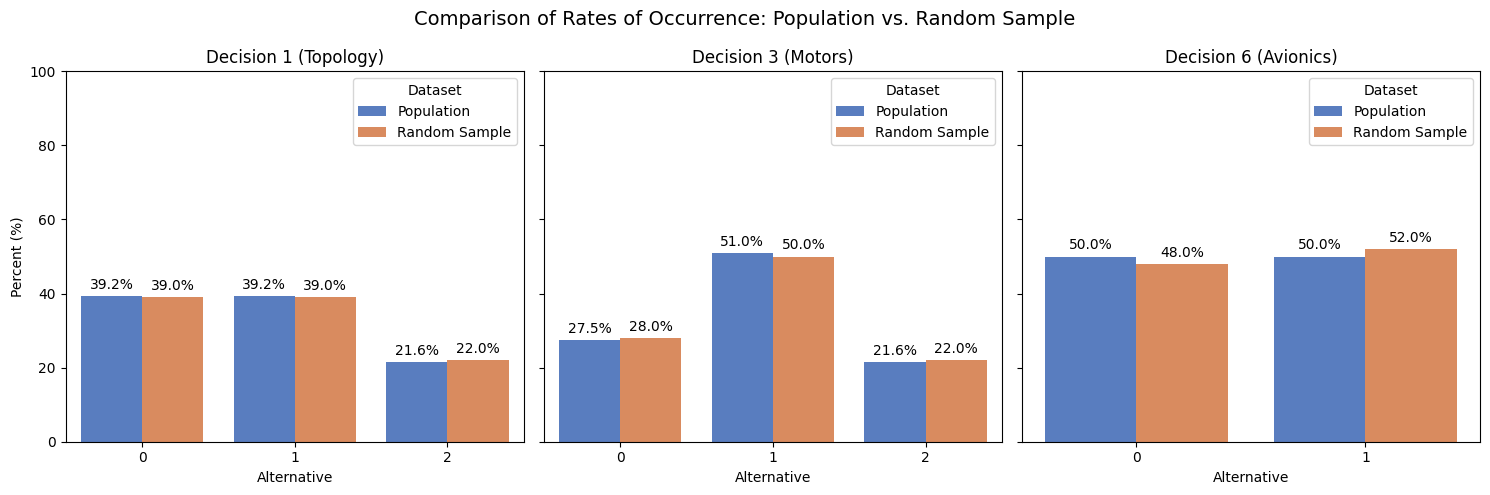

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the fully constrained architectural space from Exercise 1
df = pd.read_csv('arch_space.csv')

# 2. Perform Stratified Random Sampling (n=100)
# Stratifying on D1 (Propulsion) and D3 (Motor Count) to ensure proportional representation
target_n = 100

# Calculate exact sample sizes per stratum based on population proportions
strata_counts = df.groupby(['d1', 'd3']).size()
strata_props = strata_counts / len(df)
sample_sizes = (strata_props * target_n).round().astype(int)

# Adjust for rounding errors to ensure exactly 100 samples
while sample_sizes.sum() < target_n:
    sample_sizes.iloc[sample_sizes.argmin()] += 1
while sample_sizes.sum() > target_n:
    sample_sizes.iloc[sample_sizes.argmax()] -= 1

# Extract the stratified sample
sample_df = pd.DataFrame()
for (d1_val, d3_val), size in sample_sizes.items():
    stratum = df[(df['d1'] == d1_val) & (df['d3'] == d3_val)]
    if size > 0:
        sample_df = pd.concat([sample_df, stratum.sample(n=size, random_state=42)])

sample_df = sample_df.sample(frac=1, random_state=42).reset_index(drop=True) # Shuffle final sample

# 3. Format into vector representation strings for the docx
vectors = []
for _, row in sample_df.iterrows():
    d4_str = f"{int(row['d4_1'])}{int(row['d4_2'])}{int(row['d4_3'])}{int(row['d4_4'])}{int(row['d4_5'])}{int(row['d4_6'])}"
    d7_str = f"{int(row['d7_1'])}{int(row['d7_2'])}{int(row['d7_3'])}{int(row['d7_4'])}{int(row['d7_5'])}{int(row['d7_6'])}"
    vec = f"{int(row['d1'])} - {int(row['d2'])} - {int(row['d3'])} - {d4_str} - {int(row['d5'])} - {int(row['d6'])} - {d7_str} - {int(row['d8'])}"
    vectors.append(vec)

print(f"--- Generated {len(vectors)} Stratified Random Architectures ---")
for i, v in enumerate(vectors):
    print(f"Arch {i+1:03d}: {v}")

# Save the 100 N random sample to CSV for submission
pd.DataFrame(vectors, columns=['Vector_Representation']).to_csv('stratified_random_sample.csv', index=False)

# 4. Generate the Quantitative Justification Plot (Comparing Frequencies)
# Prepare data for plotting
decisions_to_plot = ['d1', 'd3', 'd6']
plot_titles = ['Decision 1 (Topology)', 'Decision 3 (Motors)', 'Decision 6 (Avionics)']

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
fig.suptitle('Comparison of Rates of Occurrence: Population vs. Random Sample', fontsize=14)

for i, (col, title) in enumerate(zip(decisions_to_plot, plot_titles)):
    # Calculate percentages
    pop_pct = df[col].value_counts(normalize=True).sort_index() * 100
    samp_pct = sample_df[col].value_counts(normalize=True).sort_index() * 100

    # Combine into a single dataframe for seaborn
    plot_df = pd.DataFrame({
        'Alternative': pop_pct.index.tolist() + samp_pct.index.tolist(),
        'Percent (%)': pop_pct.tolist() + samp_pct.tolist(),
        'Dataset': ['Population'] * len(pop_pct) + ['Random Sample'] * len(samp_pct)
    })

    sns.barplot(data=plot_df, x='Alternative', y='Percent (%)', hue='Dataset', ax=axes[i], palette='muted')
    axes[i].set_title(title)
    axes[i].set_ylim(0, 100)

    # Add percentage labels on top of bars
    for container in axes[i].containers:
        axes[i].bar_label(container, fmt='%.1f%%', padding=3)

plt.tight_layout()
plt.show()